In [ ]:
"""
PLOTTING ONLY:
- Reads the combined layer 'eflows_all_years' from a GeoPackage.
- Produces and DISPLAYS:
  (1) Stacked bar charts of area (km²) per year by class, for each variable,
  (2) Stacked bar charts of area share (0-1) per year by class, for each variable,
  (3) Histograms of temporal consistency per variable,
  (4) First vs last year side-by-side maps for TypeLow, TypeInter, TypeHigh.

Assumptions:
- GeoPackage exists at: example_output_data/shapefile_output_eflows/eflows_28992_all_years.gpkg
- Combined layer is named: 'eflows_all_years'
- Variables are: TypeLow, TypeInter, TypeHigh with classes in {-1, 0, 1}
- Initial CRS of features may be EPSG:4326; areas/maps are computed in EPSG:28992.
- No files are written—plots are shown with plt.show().
"""

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import FuncFormatter
from pathlib import Path
import hashlib
import contextily as cx

In [ ]:
# ----------------------------
# HELPERS
# ----------------------------

# CRS names
CRS_SOURCE = "EPSG:4326"   # WGS 84 (lat/lon)
CRS_AREA   = "EPSG:28992"  # Amersfoort / RD New (meters; good for NL)

def to_int_class(series: pd.Series) -> pd.Series:
    """Convert class series to numeric values; preserve decimals (e.g. 0.5) and NaNs."""
    return pd.to_numeric(series, errors="coerce").astype("Float64")

def force_area_crs(gdf: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    """
    Ensure GeoDataFrame is in EPSG:28992 for area and map plotting:
    - If CRS missing: assume EPSG:4326 (per data), then project to 28992.
    - If CRS=4326: project to 28992.
    - Else: project to 28992 if needed.
    """
    if gdf.crs is None:
        gdf = gdf.set_crs(CRS_SOURCE).to_crs(CRS_AREA)
    else:
        epsg = gdf.crs.to_epsg()
        if epsg != 28992:
            gdf = gdf.to_crs(CRS_AREA)
    return gdf

def ensure_area_columns(gdf: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    """Ensure per-feature areas exist (in km²)."""
    if "area_km2" not in gdf.columns:
        gdf["area_km2"] = gdf["area_m2"] / 1_000_000.0
    return gdf

def detect_or_build_cell_id(gdf: gpd.GeoDataFrame) -> tuple[gpd.GeoDataFrame, str]:
    """
    Find a stable cell identifier column or create one from geometry hash (WKB).
    """
    candidates = ["cell_id", "CellID", "face_id", "FaceID", "fid",
                  "mesh2d_face", "ugrid_face", "element", "elem_id", "poly_id"]
    for c in candidates:
        if c in gdf.columns:
            return gdf, c
    gdf = gdf.copy()
    gdf["cell_id"] = gdf.geometry.apply(lambda geom: hashlib.md5(geom.wkb).hexdigest())
    return gdf, "cell_id"

In [ ]:
# ----------------------------
# CONFIG
# ----------------------------

# Data location (adjust if needed)
data_dir = Path(r'example_output_data_20260223/output_eflows')
gpkg_path = data_dir / "eflows_28992_all_years.gpkg"
combined_layer_name = "eflows_all_years"

# Variables / classes to visualize
variables = ["low_flow", "inter_flow", "high_flow"]
classes   = [-1, 1, 2]

# Colors per class (consistent across all charts and maps)
class_colors = {
    -1: "#8a8a8a",  # grey
     1: "#C45A5A",  # red
     2: "#4C9A6A",  # green
}

class_labels = {
    -1: "None",
     1: "Bad flow",
     2: "Good flow",
}

In [58]:
# ----------------------------
# LOAD COMBINED LAYER & PREP
# ----------------------------

if not gpkg_path.exists():
    raise FileNotFoundError(f"GeoPackage not found: {gpkg_path}")

# Read combined layer
gdf_all = gpd.read_file(gpkg_path, layer=combined_layer_name)

# Project to EPSG:28992 for area & maps
gdf_all = force_area_crs(gdf_all)
gdf_all = ensure_area_columns(gdf_all)

# Year sanity check
if "year" not in gdf_all.columns:
    raise RuntimeError("Combined layer lacks a 'year' column.")

years = (pd.to_numeric(gdf_all["year"], errors="coerce")
         .dropna().astype(int).sort_values().unique().tolist())
if not years:
    raise RuntimeError("No valid years found in 'year' field.")
first_year, last_year = years[0], years[-1]
gdf_all

KeyboardInterrupt: 

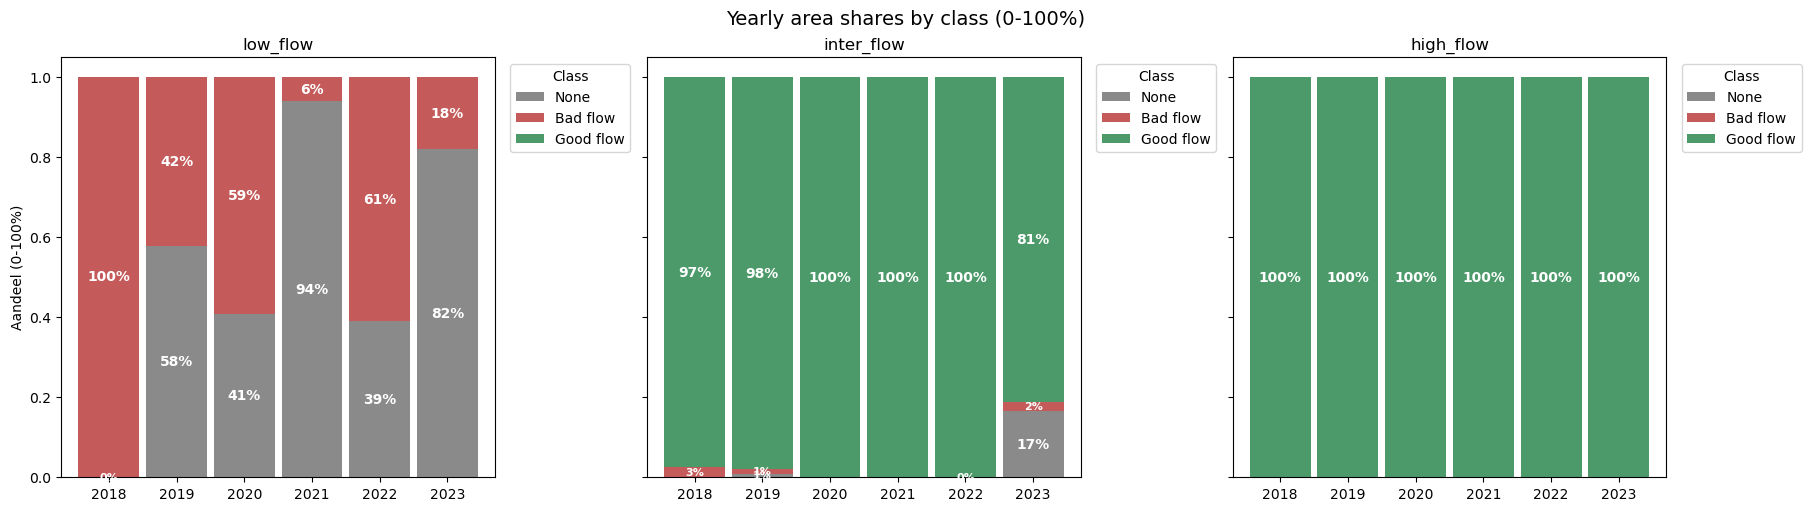

In [ ]:
# Custom plotting for eflows variables, with absolute and relative area charts, and maps for first vs last year.

# ----------------------------
# YEARLY AREA PLOT (single script)
# mode: "absolute" (km²) or "relative" (share 0–1)
# ----------------------------

def plot_yearly_area(mode="absolute"):
    is_relative = (mode == "relative")

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True, sharey=True)

    for ax, var in zip(axes, variables):
        if var not in gdf_all.columns:
            ax.set_title(f"{var} — column missing")
            ax.axis("off")
            continue

        # Prepare per-year, per-class km²
        s_class = to_int_class(gdf_all[var])
        dfv = gdf_all[["year", "area_km2"]].copy()
        dfv["class"] = s_class
        dfv = dfv.dropna(subset=["class", "year"]).copy()
        dfv["year"] = dfv["year"].astype(int)
        dfv["class"] = dfv["class"].astype(int)

        by = dfv.groupby(["year", "class"], as_index=False)["area_km2"].sum()
        pv = (
            by.pivot_table(index="year", columns="class", values="area_km2", aggfunc="sum")
              .reindex(index=years)
              .fillna(0.0)
        )

        # Ensure ordered class columns
        for cl in classes:
            if cl not in pv.columns:
                pv[cl] = 0.0
        pv = pv[[cl for cl in classes]]

        # Absolute or relative data
        if is_relative:
            totals = pv.sum(axis=1).replace(0, np.nan)
            plot_df = pv.div(totals, axis=0).fillna(0.0)
            ylabel = "Aandeel (0-100%)"
            title_suffix = ""
        else:
            plot_df = pv
            ylabel = "Area (km²)"
            title_suffix = ""

        plot_df.plot(
            kind="bar",
            stacked=True,
            color=[class_colors[c] for c in classes],
            ax=ax,
            width=0.9,
            edgecolor="none"
        )

        # Segment labels (optional: only for absolute)
        if not is_relative:
            for container in ax.containers:
                for bar, v in zip(container, container.datavalues):
                    if v <= 0.5:
                        continue
                    fs = 7 if v < 5 else 9
                    ax.text(
                        bar.get_x() + bar.get_width() / 2,
                        bar.get_y() + bar.get_height() / 2,
                        f"{v:.0f} km²",
                        ha="center",
                        va="center",
                        fontsize=fs,
                        fontweight="bold",
                        color="white",
                    )

        # Segment labels (optional: only for absolute)
        if is_relative:
            for container in ax.containers:
                for bar, v in zip(container, container.datavalues):
                    if v <= 0:
                        continue
                    fs = 8 if v < 0.05 else 10
                    ax.text(
                        bar.get_x() + bar.get_width() / 2,
                        bar.get_y() + bar.get_height() / 2,
                        f"{v * 100:.0f}%",
                        ha="center",
                        va="center",
                        fontsize=fs,
                        fontweight="bold",
                        color="white",
                    )

        ax.set_title(f"{var}{title_suffix}")
        ax.set_xlabel(None)
        ax.set_xticklabels(plot_df.index.astype(str), rotation=0, fontsize=10)
        ax.set_ylabel(ylabel)
        ax.legend(
            title="Class",
            labels=[f"{class_labels.get(c, str(c))}" for c in classes],
            frameon=True,
            bbox_to_anchor=(1.02, 1),
            loc="upper left"
        )

    fig.suptitle(
        "Yearly area shares by class (0-100%)" if is_relative else "Yearly area by class (km²)",
        fontsize=14
    )
    plt.show()


# ---- switch here ----
plot_mode = "relative"   # change to "relative"
plot_yearly_area(mode=plot_mode)


In [ ]:
# # ----------------------------
# # C) TEMPORAL CONSISTENCY — HISTOGRAMS
# # Definition per (cell, variable):
# #   consistency = (# years in cell's modal class) / (# valid years)
# # ----------------------------
# # Ensure a cell id exists or build one (not strictly required for maps/bars, but needed here)
# id_col = None
# for c in ["cell_id", "CellID", "face_id", "FaceID", "fid",
#           "mesh2d_face", "ugrid_face", "element", "elem_id", "poly_id"]:
#     if c in gdf_all.columns:
#         id_col = c
#         break
# if id_col is None:
#     gdf_all = gdf_all.copy()
#     gdf_all["cell_id"] = gdf_all.geometry.apply(lambda geom: hashlib.md5(geom.wkb).hexdigest())
#     id_col = "cell_id"

# # Compute consistency per variable
# fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True, sharey=True)

# for ax, var in zip(axes, variables):
#     if var not in gdf_all.columns:
#         ax.set_title(f"{var} — column missing")
#         ax.axis("off")
#         continue

#     # Build long form (cell, year, class)
#     s_class = to_int_class(gdf_all[var])
#     dfv = gdf_all[[id_col, "year"]].copy()
#     dfv["class"] = s_class
#     dfv = dfv.dropna(subset=["class", "year"]).copy()

#     if dfv.empty:
#         ax.set_title(f"{var} — no data")
#         continue

#     # Modal class per cell
#     modal = (dfv.groupby(id_col)["class"]
#                .agg(lambda x: pd.Series(x).value_counts().idxmax())
#                .rename("modal_class")
#                .reset_index())

#     tmp = dfv.merge(modal, on=id_col, how="left")
#     tmp["is_modal"] = (tmp["class"] == tmp["modal_class"]).astype(int)

#     cons = (tmp.groupby(id_col, as_index=False)
#             .agg(n_years=("is_modal", "size"),
#                  n_modal=("is_modal", "sum")))
#     cons["consistency"] = np.where(cons["n_years"] > 0,
#                                    cons["n_modal"] / cons["n_years"], np.nan)

#     # Plot histogram of consistency (0–1)
#     ax.hist(cons["consistency"].dropna(), bins=np.linspace(0, 1, 21),
#             color="#3182bd", edgecolor="white")
#     ax.set_title(f"{var} — Temporal consistency (fraction in modal class)")
#     ax.set_xlabel("Fraction (0–1)")
#     ax.set_ylabel("Number of cells")

# fig.suptitle("Temporal consistency distributions by variable", fontsize=14)
# plt.show()

In [ ]:
clip_gpkg_path = Path(r"P:\11211045-spongeworks\02_GIS\Vecht\stroomgebied_id9_rd.shp")

gdf_provincies = gpd.read_file(clip_gpkg_path)
gdf_provincies = force_area_crs(gdf_provincies)
gdf_provincies

# ----------------------------
# D) MAPS — ONE FIGURE PER YEAR (saved to disk)
# ----------------------------

def add_north_arrow(ax, x=0.95, y=0.86, length=0.12):
    ax.annotate(
        "N",
        xy=(x, y + length),
        xytext=(x, y),
        xycoords="axes fraction",
        textcoords="axes fraction",
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold",
        color="black",
        arrowprops=dict(arrowstyle="-|>", color="black", lw=1.5),
        zorder=20
    )

def plot_all_year_maps_and_save(var: str, out_dir: Path):
    if var not in gdf_all.columns:
        print(f"Variable '{var}' not found.")
        return

    out_dir.mkdir(parents=True, exist_ok=True)

    for yr in years:
        g = gdf_all[gdf_all["year"] == yr].copy()
        g["_class"] = to_int_class(g[var])
        g = g.dropna(subset=["_class"]).copy()
        g["_class"] = g["_class"].astype(int)
        g["_color"] = g["_class"].map(class_colors).fillna("#999999")

        fig, ax = plt.subplots(1, 1, figsize=(8, 8), constrained_layout=True)

        if not g.empty:
            g.plot(ax=ax, color=g["_color"], linewidth=0.1, edgecolor="none", alpha=0.95, zorder=5)
            cx.add_basemap(
                ax,
                crs=g.crs,
                source=cx.providers.CartoDB.PositronNoLabels,
                attribution=False,
                zorder=0
            )

        gdf_provincies.boundary.plot(ax=ax, color="#333333", linewidth=0.5, zorder=4, alpha=0.7, linestyle="--")

        ax.set_title(f"{var} — {yr}")
        ax.set_axis_off()
        add_north_arrow(ax)

        patches = [
            mpatches.Patch(color=class_colors[c], label=class_labels.get(c, str(c)))
            for c in classes
        ]
        # ax.legend(handles=patches, loc="upper left", frameon=True, title="Class")
        leg = ax.legend(handles=patches, loc="upper left", frameon=True, title="Class")
        leg.set_zorder(1000)
        leg.get_frame().set_alpha(1.0)
        leg.get_frame().set_facecolor("white")

        out_file = out_dir / f"{var}_{yr}.png"
        fig.savefig(out_file, dpi=300, bbox_inches="tight")
        plt.close(fig)

    print(f"Saved maps for '{var}' to: {out_dir}")

# Save folder
maps_out_dir = data_dir / "maps_all_years"

# Run for all variables
for var in variables:
    plot_all_year_maps_and_save(var, maps_out_dir)


Saved maps for 'low_flow' to: example_output_data_20260223\output_eflows\maps_all_years
Saved maps for 'inter_flow' to: example_output_data_20260223\output_eflows\maps_all_years
Saved maps for 'high_flow' to: example_output_data_20260223\output_eflows\maps_all_years


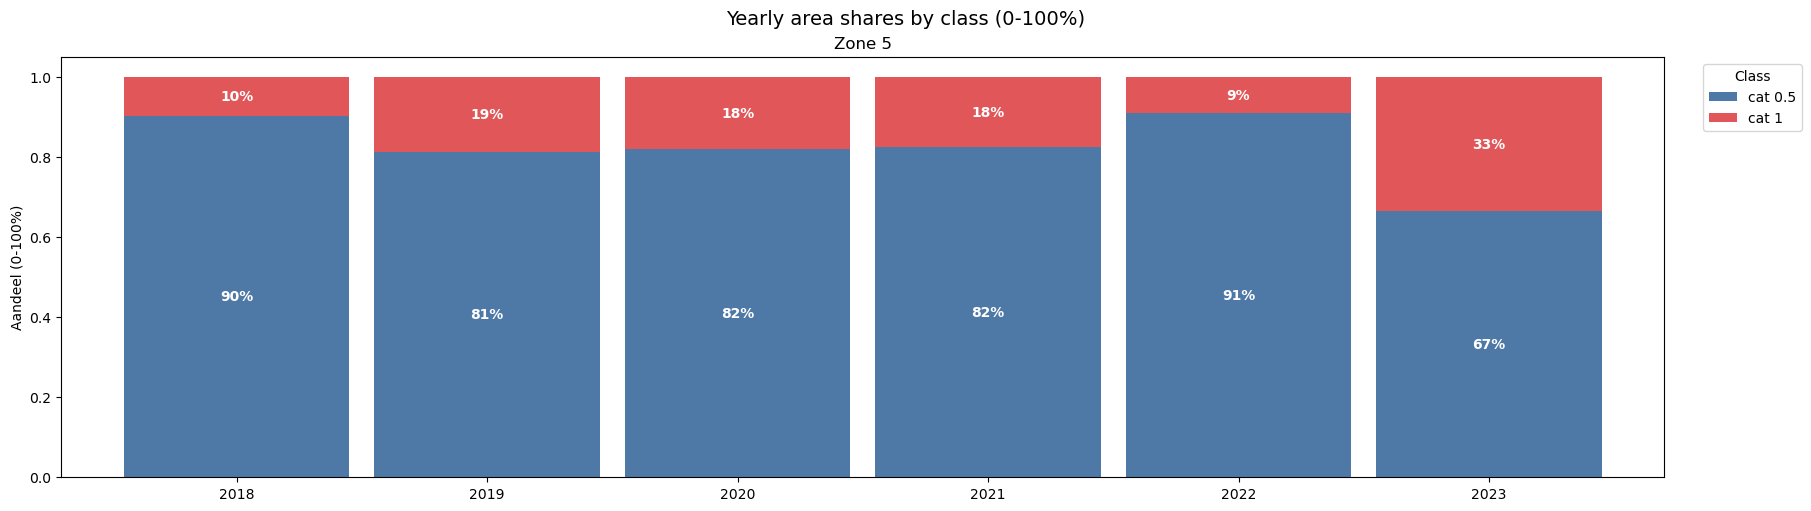

In [60]:
# Custom plotting for eflows variables, with absolute and relative area charts, and maps for first vs last year.

# ----------------------------
# CONFIG
# ----------------------------

# Data location (adjust if needed)
data_dir = Path(r'example_output_data_20260223/output_Inundation_Zones')
gpkg_path = data_dir / "Inundation_Zones_28992_all_years.gpkg"
combined_layer_name = "Inundation_Zones_all_years"

# ----------------------------
# LOAD COMBINED LAYER & PREP
# ----------------------------

if not gpkg_path.exists():
    raise FileNotFoundError(f"GeoPackage not found: {gpkg_path}")

# Read combined layer
gdf_all = gpd.read_file(gpkg_path, layer=combined_layer_name)

# Project to EPSG:28992 for area & maps
gdf_all = force_area_crs(gdf_all)
gdf_all = ensure_area_columns(gdf_all)

# Year sanity check
if "year" not in gdf_all.columns:
    raise RuntimeError("Combined layer lacks a 'year' column.")

years = (pd.to_numeric(gdf_all["year"], errors="coerce")
         .dropna().astype(int).sort_values().unique().tolist())
if not years:
    raise RuntimeError("No valid years found in 'year' field.")
first_year, last_year = years[0], years[-1]
gdf_all

# -------

# Variables / classes to visualize
variables = ["Zone 5",]
classes   = [0.5, 1] # 0

# Colors per class (consistent across all charts and maps)
class_colors = {
    # 0.0: "#66666616",  # grey
    0.5:  "#4E79A7",  # blue
    1:  "#E15759",  # red
}

class_labels = {
    # 0.0: "No inundation",
    0.5: "cat 0.5",
    1: "cat 1",
}

# ----------------------------
# YEARLY AREA PLOT (single script)
# mode: "absolute" (km²) or "relative" (share 0–1)
# ----------------------------

def plot_yearly_area(mode="absolute"):
    is_relative = (mode == "relative")

    fig, axes = plt.subplots(
        1, len(variables), figsize=(18, 5), constrained_layout=True, sharey=True
    )

    # Works for both a single subplot and multiple subplots
    axes = np.atleast_1d(axes).ravel().tolist()

    for ax, var in zip(axes, variables):
        if var not in gdf_all.columns:
            ax.set_title(f"{var} — column missing")
            ax.axis("off")
            continue

        # Prepare per-year, per-class km²
        s_class = to_int_class(gdf_all[var])
        dfv = gdf_all[["year", "area_km2"]].copy()
        dfv["class"] = s_class
        dfv = dfv.dropna(subset=["class", "year"]).copy()
        dfv["year"] = dfv["year"].astype(int)
        dfv["class"] = pd.to_numeric(dfv["class"], errors="coerce").round(1)

        by = dfv.groupby(["year", "class"], as_index=False)["area_km2"].sum()
        pv = (
            by.pivot_table(index="year", columns="class", values="area_km2", aggfunc="sum")
              .reindex(index=years)
              .fillna(0.0)
        )

        # Ensure ordered class columns
        for cl in classes:
            if cl not in pv.columns:
                pv[cl] = 0.0
        pv = pv[[cl for cl in classes]]

        # Absolute or relative data
        if is_relative:
            totals = pv.sum(axis=1).replace(0, np.nan)
            plot_df = pv.div(totals, axis=0).fillna(0.0)
            ylabel = "Aandeel (0-100%)"
            title_suffix = ""
        else:
            plot_df = pv
            ylabel = "Area (km²)"
            title_suffix = ""

        plot_df.plot(
            kind="bar",
            stacked=True,
            color=[class_colors[c] for c in classes],
            ax=ax,
            width=0.9,
            edgecolor="none"
        )

        # Segment labels (optional: only for absolute)
        if not is_relative:
            for container in ax.containers:
                for bar, v in zip(container, container.datavalues):
                    if v <= 0.5:
                        continue
                    fs = 7 if v < 5 else 9
                    ax.text(
                        bar.get_x() + bar.get_width() / 2,
                        bar.get_y() + bar.get_height() / 2,
                        f"{v:.0f} km²",
                        ha="center",
                        va="center",
                        fontsize=fs,
                        fontweight="bold",
                        color="white",
                    )

        # Segment labels (optional: only for absolute)
        if is_relative:
            for container in ax.containers:
                for bar, v in zip(container, container.datavalues):
                    if v <= 0:
                        continue
                    fs = 8 if v < 0.05 else 10
                    ax.text(
                        bar.get_x() + bar.get_width() / 2,
                        bar.get_y() + bar.get_height() / 2,
                        f"{v * 100:.0f}%",
                        ha="center",
                        va="center",
                        fontsize=fs,
                        fontweight="bold",
                        color="white",
                    )

        ax.set_title(f"{var}{title_suffix}")
        ax.set_xlabel(None)
        ax.set_xticklabels(plot_df.index.astype(str), rotation=0, fontsize=10)
        ax.set_ylabel(ylabel)
        ax.legend(
            title="Class",
            labels=[f"{class_labels.get(c, str(c))}" for c in classes],
            frameon=True,
            bbox_to_anchor=(1.02, 1),
            loc="upper left"
        )

    fig.suptitle(
        "Yearly area shares by class (0-100%)" if is_relative else "Yearly area by class (km²)",
        fontsize=14
    )
    plt.show()


# ---- switch here ----
plot_mode = "relative"   # change to "relative"
plot_yearly_area(mode=plot_mode)


In [64]:
clip_gpkg_path = Path(r"P:\11211045-spongeworks\02_GIS\Vecht\stroomgebied_id9_rd.shp")

gdf_provincies = gpd.read_file(clip_gpkg_path)
gdf_provincies = force_area_crs(gdf_provincies)
gdf_provincies

# Colors per class (consistent across all charts and maps)
class_colors = {
    0.0: "#D5D5D54B",  # grey
    0.5:  "#4E79A7",  # blue
    1:  "#E15759",  # red
}

class_labels = {
    0.0: "No inundation",
    0.5: "cat 0.5",
    1: "cat 1",
}

# ----------------------------
# D) MAPS — ONE FIGURE PER YEAR (saved to disk)
# ----------------------------

def add_north_arrow(ax, x=0.95, y=0.86, length=0.12):
    ax.annotate(
        "N",
        xy=(x, y + length),
        xytext=(x, y),
        xycoords="axes fraction",
        textcoords="axes fraction",
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold",
        color="black",
        arrowprops=dict(arrowstyle="-|>", color="black", lw=1.5),
        zorder=20
    )

def plot_all_year_maps_and_save(var: str, out_dir: Path):
    if var not in gdf_all.columns:
        print(f"Variable '{var}' not found.")
        return

    out_dir.mkdir(parents=True, exist_ok=True)

    for yr in years:
        g = gdf_all[gdf_all["year"] == yr].copy()

        # Keep float classes (e.g., 0.5), only coerce to numeric
        g["_class"] = pd.to_numeric(g[var], errors="coerce")
        g = g.dropna(subset=["_class"]).copy()

        # 0.0 -> transparent grey, others from class_colors
        g["_color"] = np.where(
            g["_class"].eq(0.0),
            class_colors.get(0, "#33ff0027"),
            g["_class"].map(class_colors).fillna("#99999900")
        )

        fig, ax = plt.subplots(1, 1, figsize=(8, 8), constrained_layout=True)

        if not g.empty:
            g.plot(ax=ax, color=g["_color"], linewidth=0.1, edgecolor="none", alpha=0.95, zorder=5)
            cx.add_basemap(
                ax,
                crs=g.crs,
                source=cx.providers.CartoDB.PositronNoLabels,
                attribution=False,
                zorder=0
            )

        gdf_provincies.boundary.plot(ax=ax, color="#333333", linewidth=0.5, zorder=4, alpha=0.7, linestyle="--")

        ax.set_title(f"{var} — {yr}")
        ax.set_axis_off()
        add_north_arrow(ax)

        legend_classes = [0] + [c for c in classes if c != 0]
        patches = [
            mpatches.Patch(color=class_colors[c], label=class_labels.get(c, str(c)))
            for c in legend_classes
            if c in class_colors
        ]
        leg = ax.legend(handles=patches, loc="upper left", frameon=True, title="Class")
        leg.set_zorder(1000)
        leg.get_frame().set_alpha(1.0)
        leg.get_frame().set_facecolor("white")

        out_file = out_dir / f"{var}_{yr}.png"
        fig.savefig(out_file, dpi=300, bbox_inches="tight")
        plt.close(fig)

    print(f"Saved maps for '{var}' to: {out_dir}")

# Save folder
maps_out_dir = data_dir / "maps_all_years"

# Run for all variables
for var in variables:
    plot_all_year_maps_and_save(var, maps_out_dir)


Saved maps for 'Zone 5' to: example_output_data_20260223\output_Inundation_Zones\maps_all_years


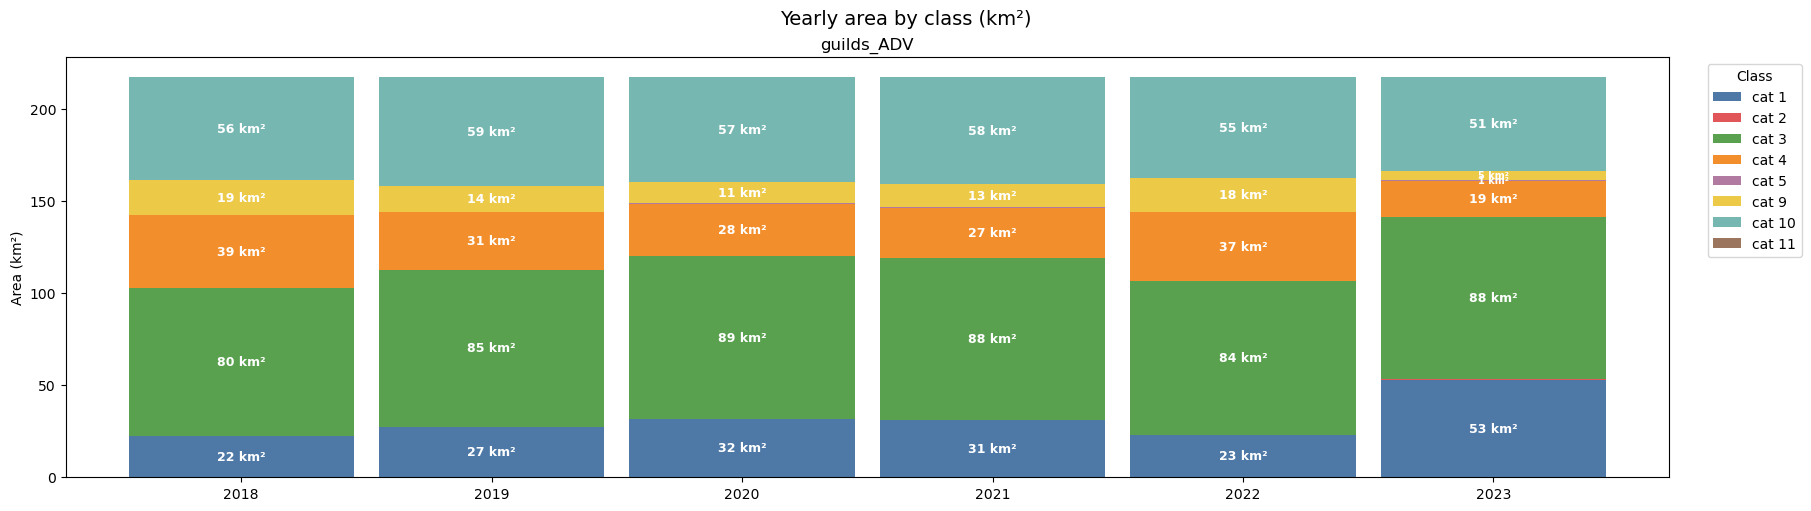

In [ ]:
# Custom plotting for eflows variables, with absolute and relative area charts, and maps for first vs last year.

# ----------------------------
# CONFIG
# ----------------------------

# Data location (adjust if needed)
data_dir = Path(r'example_output_data_20260223/output_NearBottomFV')
gpkg_path = data_dir / "NearBottomFV_28992_all_years.gpkg"
combined_layer_name = "NearBottomFV_all_years"

# ----------------------------
# LOAD COMBINED LAYER & PREP
# ----------------------------

if not gpkg_path.exists():
    raise FileNotFoundError(f"GeoPackage not found: {gpkg_path}")

# Read combined layer
gdf_all = gpd.read_file(gpkg_path, layer=combined_layer_name)

# Project to EPSG:28992 for area & maps
gdf_all = force_area_crs(gdf_all)
gdf_all = ensure_area_columns(gdf_all)

# Year sanity check
if "year" not in gdf_all.columns:
    raise RuntimeError("Combined layer lacks a 'year' column.")

years = (pd.to_numeric(gdf_all["year"], errors="coerce")
         .dropna().astype(int).sort_values().unique().tolist())
if not years:
    raise RuntimeError("No valid years found in 'year' field.")
first_year, last_year = years[0], years[-1]
gdf_all

# -------

# Variables / classes to visualize
variables = ["guilds_ADV",]
classes   = [1, 2, 3, 4, 5, 9, 10, 11]

# Colors per class (consistent across all charts and maps)
class_colors = {
    1:  "#4E79A7",  # blue
    2:  "#E15759",  # red
    3:  "#59A14F",  # green
    4:  "#F28E2B",  # orange
    5:  "#B07AA1",  # purple
    9:  "#EDC948",  # yellow
    10: "#76B7B2",  # teal
    11: "#9C755F",  # brown
}

class_labels = {
    1: "cat 1",
    2: "cat 2",
    3: "cat 3",
    4: "cat 4",
    5: "cat 5",
    9: "cat 9",
    10: "cat 10",
    11: "cat 11",
}

# ----------------------------
# YEARLY AREA PLOT (single script)
# mode: "absolute" (km²) or "relative" (share 0–1)
# ----------------------------

def plot_yearly_area(mode="absolute"):
    is_relative = (mode == "relative")

    fig, axes = plt.subplots(
        1, len(variables), figsize=(18, 5), constrained_layout=True, sharey=True
    )

    # Works for both a single subplot and multiple subplots
    axes = np.atleast_1d(axes).ravel().tolist()

    for ax, var in zip(axes, variables):
        if var not in gdf_all.columns:
            ax.set_title(f"{var} — column missing")
            ax.axis("off")
            continue

        # Prepare per-year, per-class km²
        s_class = to_int_class(gdf_all[var])
        dfv = gdf_all[["year", "area_km2"]].copy()
        dfv["class"] = s_class
        dfv = dfv.dropna(subset=["class", "year"]).copy()
        dfv["year"] = dfv["year"].astype(int)
        dfv["class"] = dfv["class"].astype(int)

        by = dfv.groupby(["year", "class"], as_index=False)["area_km2"].sum()
        pv = (
            by.pivot_table(index="year", columns="class", values="area_km2", aggfunc="sum")
              .reindex(index=years)
              .fillna(0.0)
        )

        # Ensure ordered class columns
        for cl in classes:
            if cl not in pv.columns:
                pv[cl] = 0.0
        pv = pv[[cl for cl in classes]]

        # Absolute or relative data
        if is_relative:
            totals = pv.sum(axis=1).replace(0, np.nan)
            plot_df = pv.div(totals, axis=0).fillna(0.0)
            ylabel = "Aandeel (0-100%)"
            title_suffix = ""
        else:
            plot_df = pv
            ylabel = "Area (km²)"
            title_suffix = ""

        plot_df.plot(
            kind="bar",
            stacked=True,
            color=[class_colors[c] for c in classes],
            ax=ax,
            width=0.9,
            edgecolor="none"
        )

        # Segment labels (optional: only for absolute)
        if not is_relative:
            for container in ax.containers:
                for bar, v in zip(container, container.datavalues):
                    if v <= 0.5:
                        continue
                    fs = 7 if v < 5 else 9
                    ax.text(
                        bar.get_x() + bar.get_width() / 2,
                        bar.get_y() + bar.get_height() / 2,
                        f"{v:.0f} km²",
                        ha="center",
                        va="center",
                        fontsize=fs,
                        fontweight="bold",
                        color="white",
                    )

        # Segment labels (optional: only for absolute)
        if is_relative:
            for container in ax.containers:
                for bar, v in zip(container, container.datavalues):
                    if v <= 0:
                        continue
                    fs = 8 if v < 0.05 else 10
                    ax.text(
                        bar.get_x() + bar.get_width() / 2,
                        bar.get_y() + bar.get_height() / 2,
                        f"{v * 100:.0f}%",
                        ha="center",
                        va="center",
                        fontsize=fs,
                        fontweight="bold",
                        color="white",
                    )

        ax.set_title(f"{var}{title_suffix}")
        ax.set_xlabel(None)
        ax.set_xticklabels(plot_df.index.astype(str), rotation=0, fontsize=10)
        ax.set_ylabel(ylabel)
        ax.legend(
            title="Class",
            labels=[f"{class_labels.get(c, str(c))}" for c in classes],
            frameon=True,
            bbox_to_anchor=(1.02, 1),
            loc="upper left"
        )

    fig.suptitle(
        "Yearly area shares by class (0-100%)" if is_relative else "Yearly area by class (km²)",
        fontsize=14
    )
    plt.show()


# ---- switch here ----
plot_mode = "absolute"   # change to "relative"
plot_yearly_area(mode=plot_mode)


In [ ]:
clip_gpkg_path = Path(r"P:\11211045-spongeworks\02_GIS\Vecht\stroomgebied_id9_rd.shp")

gdf_provincies = gpd.read_file(clip_gpkg_path)
gdf_provincies = force_area_crs(gdf_provincies)
gdf_provincies

# ----------------------------
# D) MAPS — ONE FIGURE PER YEAR (saved to disk)
# ----------------------------

def add_north_arrow(ax, x=0.95, y=0.86, length=0.12):
    ax.annotate(
        "N",
        xy=(x, y + length),
        xytext=(x, y),
        xycoords="axes fraction",
        textcoords="axes fraction",
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold",
        color="black",
        arrowprops=dict(arrowstyle="-|>", color="black", lw=1.5),
        zorder=20
    )

def plot_all_year_maps_and_save(var: str, out_dir: Path):
    if var not in gdf_all.columns:
        print(f"Variable '{var}' not found.")
        return

    out_dir.mkdir(parents=True, exist_ok=True)

    for yr in years:
        g = gdf_all[gdf_all["year"] == yr].copy()
        g["_class"] = to_int_class(g[var])
        g = g.dropna(subset=["_class"]).copy()
        g["_class"] = g["_class"].astype(int)
        g["_color"] = g["_class"].map(class_colors).fillna("#999999")

        fig, ax = plt.subplots(1, 1, figsize=(8, 8), constrained_layout=True)

        if not g.empty:
            g.plot(ax=ax, color=g["_color"], linewidth=0.1, edgecolor="none", alpha=0.95, zorder=5)
            cx.add_basemap(
                ax,
                crs=g.crs,
                source=cx.providers.CartoDB.PositronNoLabels,
                attribution=False,
                zorder=0
            )

        gdf_provincies.boundary.plot(ax=ax, color="#333333", linewidth=0.5, zorder=4, alpha=0.7, linestyle="--")

        ax.set_title(f"{var} — {yr}")
        ax.set_axis_off()
        add_north_arrow(ax)

        patches = [
            mpatches.Patch(color=class_colors[c], label=class_labels.get(c, str(c)))
            for c in classes
        ]
        # ax.legend(handles=patches, loc="upper left", frameon=True, title="Class")
        leg = ax.legend(handles=patches, loc="upper left", frameon=True, title="Class")
        leg.set_zorder(1000)
        leg.get_frame().set_alpha(1.0)
        leg.get_frame().set_facecolor("white")

        out_file = out_dir / f"{var}_{yr}.png"
        fig.savefig(out_file, dpi=300, bbox_inches="tight")
        plt.close(fig)

    print(f"Saved maps for '{var}' to: {out_dir}")

# Save folder
maps_out_dir = data_dir / "maps_all_years"

# Run for all variables
for var in variables:
    plot_all_year_maps_and_save(var, maps_out_dir)


Saved maps for 'guilds_ADV' to: example_output_data_20260223\output_NearBottomFV\maps_all_years
